# Potencial de optimización por umbrales — zoom ciudad → barrio
### Sprint 3 — Marketing i Estratègia Comercial · v6 (15/07/2026)

*¿Qué ciudades y barrios presentan mayor potencial de optimización
considerando las reseñas, la puntuación de la zona y la disponibilidad
mínima/máxima de noches?*

## 1. Introducción: cómo vamos a proceder

Fijamos un **umbral por cada una de las 4 variables** de la pregunta y
comprobamos si hay **potencial de optimización** (está fuera del rango
deseable). El análisis se hace como un **zoom en dos niveles**:

1. **Nivel 1 — Ciudades (visión global):** qué ciudades fallan qué
   umbral y dónde se concentra el volumen. Hallazgos generales.
2. **Nivel 2 — Barrios (zoom):** bajamos al detalle, vemos qué barrios
   concretos tienen más potencial y qué acción toca. Hallazgos finos.
3. **Piloto** en las 2 ciudades con mayor **volumen** de oportunidad.

Las 4 variables **no juegan el mismo papel**: **rating y noches** son
**palancas** (mejorables → ⚠️ si hay algo que hacer); **ubicación** es un
**cualificador** (activo fijo → dice si la zona merece la inversión).

Para **barrios** exigimos **N ≥ 20** anuncios: el veredicto usa la
**mediana** (robusta) y %, así que no hace falta el 30 del TLC (ese era
para medias); 20 mantiene el % fiable y recupera mercados pequeños.

### 1.1. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, Normalize

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

### 1.2. Carga del dataset

Usamos el **clean_dataset del 13_07** (versión actualizada, 9.507 filas).

> **_Aviso:_** esta versión trae los acentos corruptos por un problema
> de codificación (`el Barri G�tic`); el símbolo `�` sustituye siempre a
> una vocal acentuada (o `ñ`/`ç`). Lo corregimos justo debajo, **solo en
> el `data` de este notebook** (no se toca el CSV), reponiendo la letra
> con la tilde/diacrítico que corresponde según el idioma del barrio
> (català en Barcelona, Girona, Mallorca y Menorca; castellano en
> Madrid y Sevilla).

In [2]:
RUTA = "../Data/clean_dataset_13_07_2026.csv"
df = pd.read_csv(RUTA)

cols = [
    "apartment_id", "neighbourhood_name", "city",
    "review_scores_rating", "review_scores_location",
    "minimum_nights", "maximum_nights",
]
data = df[cols].copy()
print("filas:", len(data))
data.head()

filas: 9507


,apartment_id,neighbourhood_name,city,review_scores_rating,review_scores_location,minimum_nights,maximum_nights
0,9701470,Sant Antoni,Barcelona,NaN,NaN,3,1125
1,13311614,la Nova Esquerra de l'Eixample,Barcelona,NaN,NaN,1,4
2,7003233,el Clot,Barcelona,84.0,9.0,3,10
3,15713525,l'Antiga Esquerra de l'Eixample,Barcelona,NaN,NaN,3,1125
4,13567392,el Raval,Barcelona,89.0,10.0,4,14


## 2. Los 4 umbrales (uno por variable de la pregunta)

| Variable | Columna | Hay potencial / acción si… | Fuente |
|---|---|---|---|
| Reseñas (calidad) | `review_scores_rating` | **≤ 4,8** (por debajo del estándar) | Superhost |
| Puntuación de zona | `review_scores_location` | *(cualifica si ≥ 4,8)* | subcategoría Superhost |
| Noches mínimas | `minimum_nights` | **fuera de 3-4** | óptimo de ingresos |
| Noches máximas | `maximum_nights` | **> 31** | régimen turístico legal |

- **Rating ≤ 4,8 = potencial.** Estándar Superhost (+22% reservas); como
  es palanca, nos interesa **lo que está por debajo** (recorrido de mejora).
- **Location ≥ 4,8 = cualifica.** No hay umbral académico absoluto; la
  ubicación es driver mayor pero **inmóvil** → solo dice si la zona
  cualifica. Anclamos al 4,8 (subcategoría Superhost).
- **Noches mín fuera de 3-4 = potencial.** Óptimo de ingresos 3-4 noches
  (+35-41% vs 1). Por debajo: rotación/limpieza; por encima: barreras.
- **Noches máx > 31 = acción legal.** Límite turístico catalán (Decreto
  159/2012) → regularización.

> **_A confirmar:_** banda de noches mín **[3,4] fija** vs desviación de
> la mediana de ciudad; y `max_nights` > 31 casi universal por el
> **default de plataforma** (1125) → regularización transversal.

**Fuentes:** AirDNA, Airbnb Help 1257, MDPI 2025, shorttermrentalz,
Decreto 159/2012.

## 3. Limpieza, escalado y banderas

Corrección de acentos corruptos en 'neighbourhood_name' (solo en `data`,
no se toca el CSV). El carácter '�' sustituye siempre a una vocal con
tilde (o ñ/ç); reponemos la grafía correcta según el idioma del barrio: català en Barcelona/Girona/Mallorca/Menorca, castellano en Madrid/Sevilla.


In [ ]:
NEIGHBOURHOOD_FIX = {
    # Barcelona (català)
    "Can Bar�": "Can Baró",
    "Diagonal Mar i el Front Mar�tim del Poblenou": "Diagonal Mar i el Front Marítim del Poblenou",
    "Proven�als del Poblenou": "Provençals del Poblenou",
    "Sant Gen�s dels Agudells": "Sant Genís dels Agudells",
    "Sant Mart� de Proven�als": "Sant Martí de Provençals",
    "Sarri�": "Sarrià",
    "Torre Bar�": "Torre Baró",
    "el Baix Guinard�": "el Baix Guinardó",
    "el Barri G�tic": "el Barri Gòtic",
    "el Bes�s i el Maresme": "el Besòs i el Maresme",
    "el Camp d'en Grassot i Gr�cia Nova": "el Camp d'en Grassot i Gràcia Nova",
    "el Congr�s i els Indians": "el Congrés i els Indians",
    "el Guinard�": "el Guinardó",
    "el Putxet i el Farr�": "el Putxet i el Farró",
    "el Tur� de la Peira": "el Turó de la Peira",
    "la Sagrada Fam�lia": "la Sagrada Família",
    "la Vila Ol�mpica del Poblenou": "la Vila Olímpica del Poblenou",
    "la Vila de Gr�cia": "la Vila de Gràcia",
    # Girona (català)
    "Arb�cies": "Arbúcies",
    "Bellcaire d'Empord�": "Bellcaire d'Empordà",
    "Besal�": "Besalú",
    "Bescan�": "Bescanó",
    "B�scara": "Bàscara",
    "Cadaqu�s": "Cadaqués",
    "Campdev�nol": "Campdevànol",
    "Castell� d'Emp�ries": "Castelló d'Empúries",
    "Celr�": "Celrà",
    "Cornell� del Terri": "Cornellà del Terri",
    "Cru�lles, Monells i Sant Sadurn� de l'Heura": "Cruïlles, Monells i Sant Sadurní de l'Heura",
    "Foix�": "Foixà",
    "Is�vol": "Isòvol",
    "La Tallada d'Empord�": "La Tallada d'Empordà",
    "Llad�": "Lladó",
    "Llan��": "Llançà",
    "Ll�via": "Llívia",
    "Mai� de Montcal": "Maià de Montcal",
    "Ma�anet de la Selva": "Maçanet de la Selva",
    "Palam�s": "Palamós",
    "Palau de Santa Eul�lia": "Palau de Santa Eulàlia",
    "Parlav�": "Parlavà",
    "Pont�s": "Pontós",
    "Puigcerd�": "Puigcerdà",
    "Rab�s": "Rabós",
    "Regenc�s": "Regencós",
    "Rupi�": "Rupià",
    "Sant Feliu de Gu�xols": "Sant Feliu de Guíxols",
    "Sant Juli� de Ramis": "Sant Julià de Ramis",
    "Sant Lloren� de la Muga": "Sant Llorenç de la Muga",
    "Sant Mart� Vell": "Sant Martí Vell",
    "Sant Mart� de Ll�mena": "Sant Martí de Llémena",
    "Sant Miquel de Fluvi�": "Sant Miquel de Fluvià",
    "Sant Pau de Seg�ries": "Sant Pau de Segúries",
    "Seriny�": "Serinyà",
    "Torroella de Fluvi�": "Torroella de Fluvià",
    "Torroella de Montgr�": "Torroella de Montgrí",
    "Tortell�": "Tortellà",
    "Ull�": "Ullà",
    "Ur�s": "Urús",
    "Vallfogona de Ripoll�s": "Vallfogona de Ripollès",
    "Ventall�": "Ventalló",
    "Vidr�": "Vidrà",
    "Vilaju�ga": "Vilajuïga",
    "Vila�r": "Vilaür",
    # Madrid (castellano)
    "Arg�elles": "Argüelles",
    "Casco Hist�rico de Barajas": "Casco Histórico de Barajas",
    "Casco Hist�rico de Vallecas": "Casco Histórico de Vallecas",
    "Casco Hist�rico de Vic�lvaro": "Casco Histórico de Vicálvaro",
    "Ciudad Jard�n": "Ciudad Jardín",
    "Concepci�n": "Concepción",
    "C�rmenes": "Cármenes",
    "El Plant�o": "El Plantío",
    "Entrev�as": "Entrevías",
    "Fontarr�n": "Fontarrón",
    "Hell�n": "Hellín",
    "Hispanoam�rica": "Hispanoamérica",
    "Jer�nimos": "Jerónimos",
    "Moscard�": "Moscardó",
    "Ni�o Jes�s": "Niño Jesús",
    "Nueva Espa�a": "Nueva España",
    "Opa�el": "Opañel",
    "Pac�fico": "Pacífico",
    "Pe�agrande": "Peñagrande",
    "San Andr�s": "San Andrés",
    "San Ferm�n": "San Fermín",
    "Tim�n": "Timón",
    "Zof�o": "Zofío",
    # Mallorca (català balear)
    "Alar�": "Alaró",
    "Alc�dia": "Alcúdia",
    "Art�": "Artà",
    "B�ger": "Búger",
    "Calvi�": "Calvià",
    "Dey�": "Deià",
    "Llub�": "Llubí",
    "Marratx�": "Marratxí",
    "Montu�ri": "Montuïri",
    "Pollen�a": "Pollença",
    "Sant Lloren� des Cardassar": "Sant Llorenç des Cardassar",
    "Santa Eug�nia": "Santa Eugènia",
    "Santa Mar�a del Cam�": "Santa Maria del Camí",
    "Santany�": "Santanyí",
    "S�ller": "Sóller",
    # Menorca (català / castellanitzat)
    "Mah�n": "Mahón",
    "Sant Llu�s": "Sant Lluís",
    # Sevilla (castellano)
    "Barrio Le�n": "Barrio León",
    "Carretera de Carmona, Mar�a Auxiliadora, Fontanal": "Carretera de Carmona, María Auxiliadora, Fontanal",
    "Doctor Barraquer, G. Renfe, Policl�nico": "Doctor Barraquer, G. Renfe, Policlínico",
    "El Roc�o": "El Rocío",
    "El Tard�n, El Carmen": "El Tardón, El Carmen",
    "Encarnaci�n, Regina": "Encarnación, Regina",
    "Heli�polis": "Heliópolis",
    "La Palmilla, Doctor Mara��n": "La Palmilla, Doctor Marañón",
    "Le�n XIII, Los Naranjos": "León XIII, Los Naranjos",
    "Nervi�n": "Nervión",
    "Prado, Parque Mar�a Luisa": "Prado, Parque María Luisa",
    "San Bartolom�": "San Bartolomé",
    "San Jos� Obrero": "San José Obrero",
    "San Juli�n": "San Julián",
    "Tiro de L�nea, Santa Genoveva": "Tiro de Línea, Santa Genoveva",
}

n_antes = data["neighbourhood_name"].astype(str).str.contains("�").sum()
data["neighbourhood_name"] = data["neighbourhood_name"].replace(NEIGHBOURHOOD_FIX)
n_despues = data["neighbourhood_name"].astype(str).str.contains("�").sum()
print("barrios con '�' antes:", n_antes, "| después:", n_despues)

barrios con '�' antes: 2086 | después: 0


El `rating` viene en **0-100** y la `location` en **0-10**; los pasamos
a **0-5** para compararlos con el 4,8.

In [4]:
data = data.dropna(
    subset=["review_scores_rating", "review_scores_location"]
)
data["rating_0_5"] = data["review_scores_rating"] / 20
data["location_0_5"] = data["review_scores_location"] / 2
print("filas tras limpiar:", len(data))

filas tras limpiar: 6902


In [5]:
U_RATING = 4.8       # estándar Superhost
U_LOCATION = 4.8     # cualificador
U_MIN_LO = 3         # banda óptima de noches mínimas
U_MIN_HI = 4
U_MAX = 31           # límite legal turístico
N_MIN = 20           # muestra mínima por barrio

data["ok_ubicacion"] = data["location_0_5"] >= U_LOCATION
data["acc_rating"] = data["rating_0_5"] <= U_RATING
data["acc_min"] = ~data["minimum_nights"].between(
    U_MIN_LO, U_MIN_HI
)
data["acc_max"] = data["maximum_nights"] > U_MAX

**Funciones de apoyo** (evaluación, veredictos, semáforo, acciones).

In [6]:
def evaluar(gdf, claves):
    g = gdf.groupby(claves)
    t = g.agg(
        n=("apartment_id", "size"),
        rating_med=("rating_0_5", "median"),
        location_med=("location_0_5", "median"),
        min_med=("minimum_nights", "median"),
        max_med=("maximum_nights", "median"),
        pct_ubic_ok=("ok_ubicacion", "mean"),
        pct_rating_bajo=("acc_rating", "mean"),
        pct_min_fuera=("acc_min", "mean"),
        pct_max_alto=("acc_max", "mean"),
    ).reset_index()
    return t


def veredictos(t):
    t = t.copy()
    t["cualifica"] = t["location_med"] >= U_LOCATION
    t["a_rating"] = t["rating_med"] <= U_RATING
    t["a_min"] = ~t["min_med"].between(U_MIN_LO, U_MIN_HI)
    t["a_max"] = t["max_med"] > U_MAX
    t["n_acciones"] = t[["a_rating", "a_min", "a_max"]].sum(axis=1)
    return t


def semaforo(t, id_cols):
    s = t.copy()
    s["ubicacion"] = s["cualifica"].map({True: "✅", False: "❌"})
    for c in ["a_rating", "a_min", "a_max"]:
        s[c] = s[c].map({True: "⚠️", False: "✅"})
    cols = id_cols + ["n", "ubicacion", "a_rating",
                      "a_min", "a_max", "n_acciones"]
    return s[cols].sort_values("n_acciones", ascending=False)


def acciones(r):
    a = []
    if not r["cualifica"]:
        a.append("ubicación débil: no priorizar")
    if r["a_rating"]:
        a.append("calidad: subir rating hacia 4,8+")
    if r["a_min"]:
        d = "subir" if r["min_med"] < U_MIN_LO else "bajar"
        a.append("noches mín: %s a 3-4" % d)
    if r["a_max"]:
        a.append("noches máx: regularizar >31")
    return " | ".join(a) if a else "sin acciones"

Construimos ya las dos tablas (ciudad y barrio) y el **índice de
accionabilidad** por barrio (media de los 3 % de potencial, 0-100).

In [7]:
ciudad = veredictos(evaluar(data, ["city"]))
ciudad["acciones"] = ciudad.apply(acciones, axis=1)

barrio = evaluar(data, ["city", "neighbourhood_name"])
barrio = veredictos(barrio[barrio["n"] >= N_MIN])
barrio["acciones"] = barrio.apply(acciones, axis=1)
barrio["score_accion"] = 100 * (
    barrio["pct_rating_bajo"]
    + barrio["pct_min_fuera"]
    + barrio["pct_max_alto"]
) / 3
foco = barrio[barrio["cualifica"]].copy()
print("barrios N>=20:", len(barrio), "| cualifican:", len(foco))

barrios N>=20: 82 | cualifican: 68


## 4. NIVEL 1 · Visión global por ciudad

Primero miramos el bosque: qué ciudades fallan qué umbral y dónde está
el volumen. `⚠️` = potencial/acción · `✅` = bien · ubicación `✅`
cualifica.

In [8]:
semaforo(ciudad, ["city"])

,city,n,ubicacion,a_rating,a_min,a_max,n_acciones
0,Barcelona,2057,✅,⚠️,⚠️,⚠️,3
1,Girona,880,✅,⚠️,⚠️,⚠️,3
2,Madrid,1614,✅,⚠️,⚠️,⚠️,3
4,Menorca,144,✅,⚠️,⚠️,⚠️,3
5,Málaga,413,✅,⚠️,⚠️,⚠️,3
6,Sevilla,424,✅,⚠️,⚠️,⚠️,3
7,Valencia,419,✅,⚠️,⚠️,⚠️,3
3,Mallorca,951,✅,⚠️,✅,⚠️,2


### 4.1. % de anuncios afectados por ciudad

In [9]:
vis = ciudad[["city", "n", "pct_ubic_ok", "pct_rating_bajo",
              "pct_min_fuera", "pct_max_alto"]].copy()
for c in ["pct_ubic_ok", "pct_rating_bajo",
          "pct_min_fuera", "pct_max_alto"]:
    vis[c] = (vis[c] * 100).round(1)
vis.sort_values("pct_rating_bajo", ascending=False)

,city,n,pct_ubic_ok,pct_rating_bajo,pct_min_fuera,pct_max_alto
0,Barcelona,2057,64.4,72.0,71.8,75.8
7,Valencia,419,63.2,67.3,79.0,75.9
5,Málaga,413,59.3,66.6,80.6,85.2
1,Girona,880,62.0,62.8,81.6,74.5
2,Madrid,1614,72.7,61.6,79.0,79.8
6,Sevilla,424,74.8,60.4,86.6,80.4
4,Menorca,144,61.1,57.6,76.4,79.9
3,Mallorca,951,59.9,51.0,73.1,84.8


### 4.2. Dónde está el volumen de oportunidad

Priorizamos por **escala**: nº de **anuncios accionables** ≈
Σ (anuncios del barrio × su accionabilidad), sobre barrios que cualifican.
Así premiamos las ciudades con **más barrios y anuncios sobre los que
actuar**, no solo la severidad.

In [10]:
foco["accionables"] = foco["n"] * foco["score_accion"] / 100
oportunidad = foco.groupby("city").agg(
    barrios=("n", "size"),
    anuncios=("n", "sum"),
    score_medio=("score_accion", "mean"),
    accionables=("accionables", "sum"),
).sort_values("accionables", ascending=False)
oportunidad.round(1)

,barrios,anuncios,score_medio,accionables
city,,,,
Barcelona,16,1495,72.2,1082.0
Madrid,11,967,72.8,725.0
Girona,16,679,73.0,499.3
Mallorca,10,460,71.4,329.7
Málaga,1,266,79.4,211.3
Sevilla,7,224,75.6,169.3
Valencia,4,126,75.3,94.0
Menorca,3,110,66.7,76.7


### 4.3. Hallazgos a nivel ciudad

In [11]:
resumen = pd.DataFrame({
    "cualifican_ubicacion": [int(ciudad["cualifica"].sum())],
    "rating<=4,8 (accion)": [int(ciudad["a_rating"].sum())],
    "noches_min_fuera": [int(ciudad["a_min"].sum())],
    "noches_max>31": [int(ciudad["a_max"].sum())],
}, index=["nº de ciudades (de 8)"])
resumen

,cualifican_ubicacion,"rating<=4,8 (accion)",noches_min_fuera,noches_max>31
nº de ciudades (de 8),8,8,7,8


Lo que aparece al mirar las 8 ciudades:

- **Ubicación: no es el problema.** Las 8 cualifican (mediana 5,0). La
  optimización **no** va por aquí; la ubicación sirve para elegir *dónde*
  invertir, no *qué* mejorar.
- **Rating: la palanca principal.** Casi todas las ciudades tienen la
  mediana **por debajo de 4,8** (solo una la cumple), con un 60-75% de
  anuncios por debajo → recorrido de calidad claro y generalizado.
- **Noches mínimas por debajo del óptimo.** La mayoría queda por debajo
  de la banda 3-4 → acción típica **subir** la estancia mínima.
- **Noches máximas: incumplimiento casi universal** por el default de
  plataforma → **regularización transversal**, no discrimina zonas.
- **El volumen se concentra en Barcelona y Madrid** (tabla 4.2): son las
  ciudades con más barrios y anuncios accionables → foco del piloto.

## 5. NIVEL 2 · Zoom por barrio

Ahora bajamos al detalle dentro de cada ciudad.

### 5.1. Semáforo de barrios (N ≥ 20)

In [12]:
print("barrios evaluados:", len(barrio))
semaforo(barrio, ["city", "neighbourhood_name"]).head(15)

barrios evaluados: 82


,city,neighbourhood_name,n,ubicacion,a_rating,a_min,a_max,n_acciones
5,Barcelona,Hostafrancs,33,✅,⚠️,⚠️,⚠️,3
284,Madrid,Universidad,162,✅,⚠️,⚠️,⚠️,3
147,Girona,Roses,76,✅,⚠️,⚠️,⚠️,3
166,Girona,Torroella de Montgrí,40,✅,⚠️,⚠️,⚠️,3
168,Girona,Tossa de Mar,35,✅,⚠️,⚠️,⚠️,3
195,Madrid,Argüelles,30,✅,⚠️,⚠️,⚠️,3
217,Madrid,Cortes,75,✅,⚠️,⚠️,⚠️,3
223,Madrid,Embajadores,229,✅,⚠️,⚠️,⚠️,3
12,Barcelona,Sant Antoni,113,✅,⚠️,⚠️,⚠️,3
236,Madrid,Justicia,103,✅,⚠️,⚠️,⚠️,3


### 5.2. Accionabilidad por barrio en cada ciudad (gradiente)

> **_Aviso:_** el dataset **no trae coordenadas**, así que **no es un
> mapa geográfico**. Por cada ciudad, sus barrios que **cualifican**,
> ordenados y coloreados con el gradiente de StaySpain
> (**amarillo = más accionable → verde = menos**).

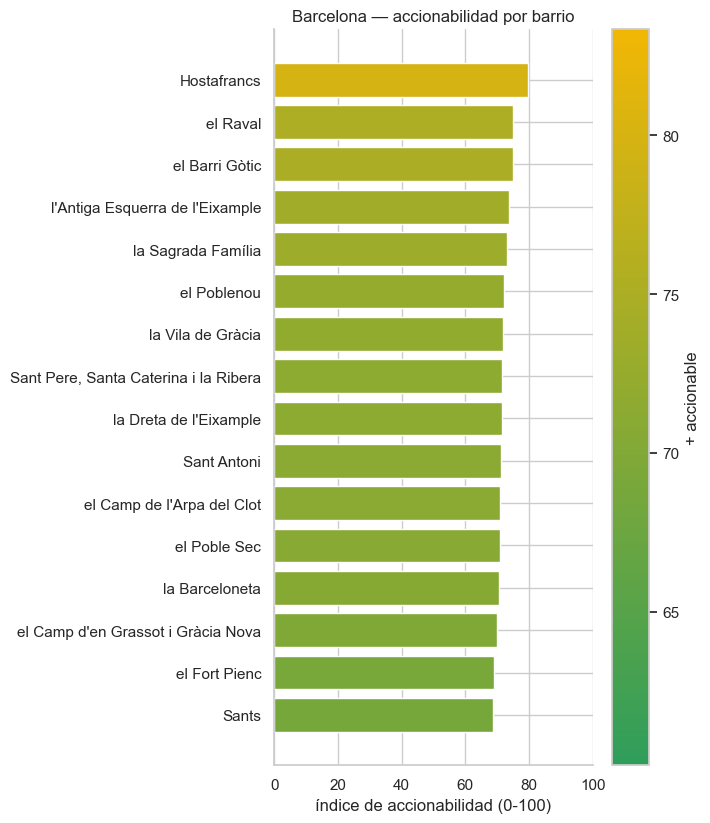

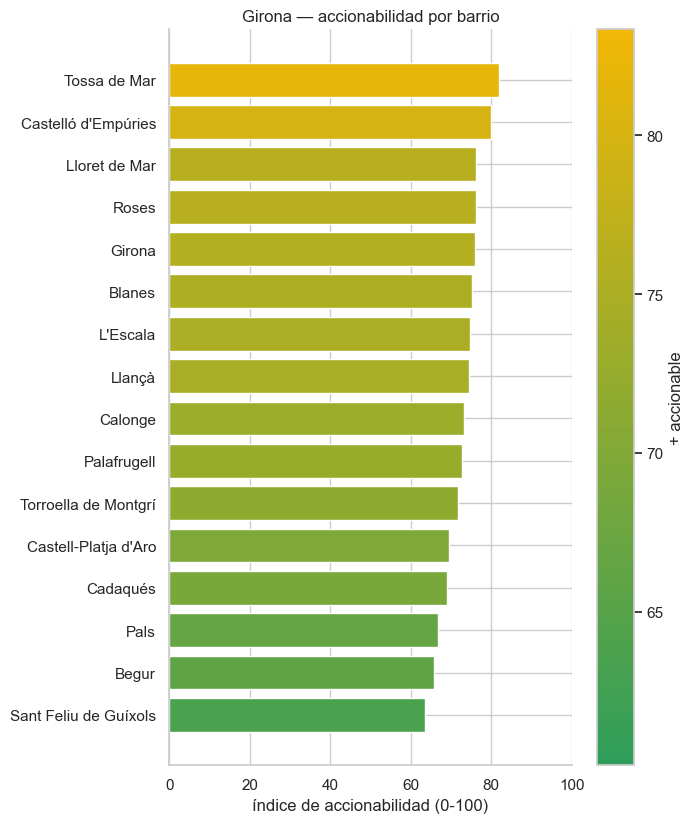

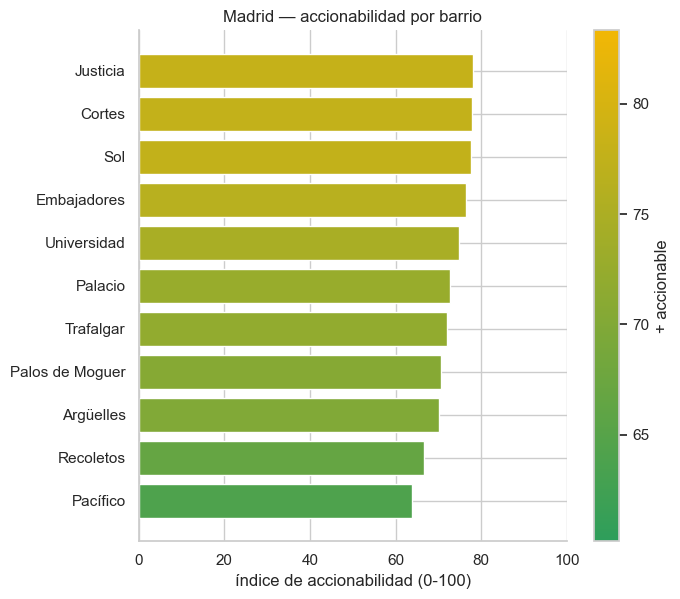

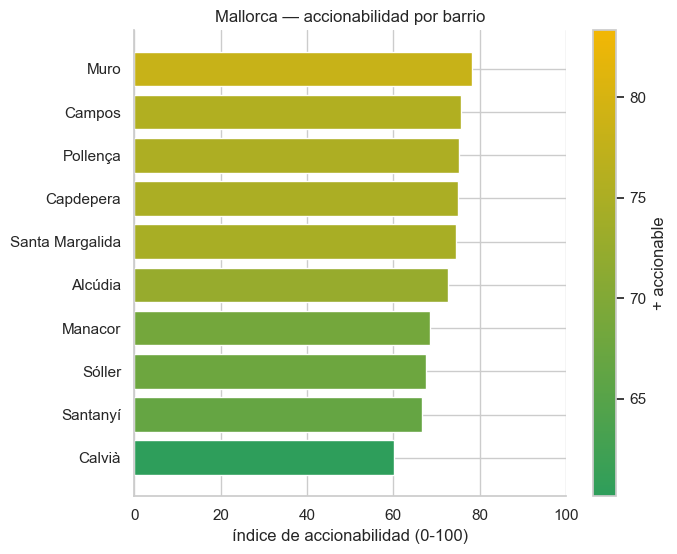

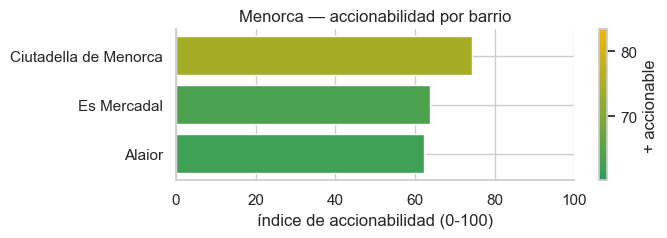

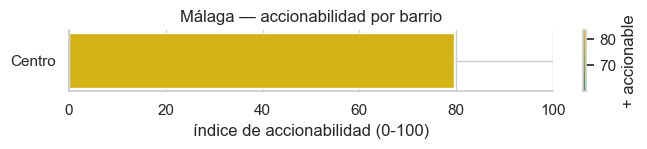

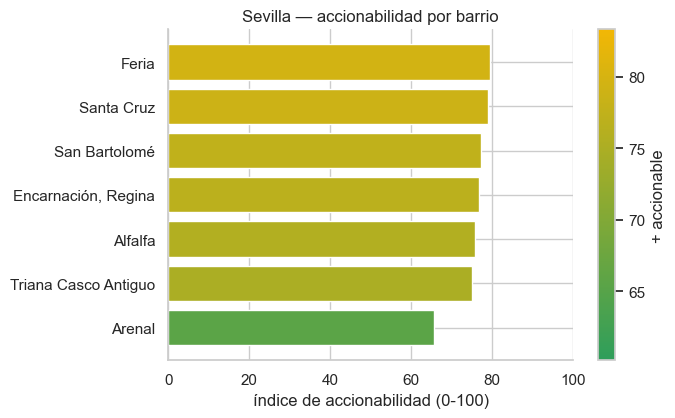

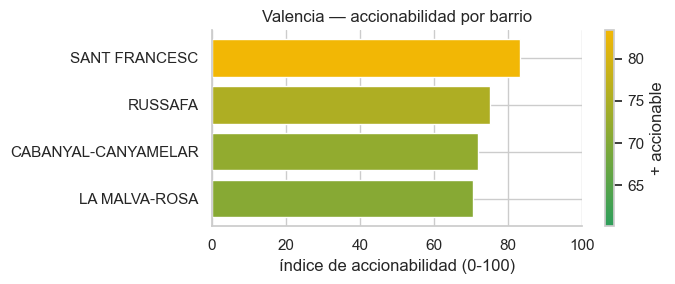

In [13]:
# Colores de marca (placeholder: ajustar al logo real).
STAY_AMARILLO = "#F2B705"
STAY_VERDE = "#2E9E5B"
cmap = LinearSegmentedColormap.from_list(
    "stayspain", [STAY_VERDE, STAY_AMARILLO]
)
norm = Normalize(foco["score_accion"].min(),
                 foco["score_accion"].max())

for city in sorted(foco["city"].unique()):
    d = foco[foco["city"] == city].sort_values("score_accion")
    fig, ax = plt.subplots(figsize=(7, 0.45 * len(d) + 1.2))
    ax.barh(d["neighbourhood_name"], d["score_accion"],
            color=cmap(norm(d["score_accion"])))
    ax.set_title("%s — accionabilidad por barrio" % city)
    ax.set_xlabel("índice de accionabilidad (0-100)")
    ax.set_xlim(0, 100)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    fig.colorbar(sm, ax=ax, label="+ accionable")
    plt.tight_layout()
    plt.show()

### 5.3. Barrios de mayor potencial (cualifican + más acciones)

In [14]:
top = foco.sort_values(
    ["score_accion", "n"], ascending=[False, False]
)
top[["city", "neighbourhood_name", "n", "n_acciones",
     "score_accion", "acciones"]].head(10).round(1)

,city,neighbourhood_name,n,n_acciones,score_accion,acciones
475,Valencia,SANT FRANCESC,22,3,83.3,"calidad: subir rating hacia 4,8+ | noches mín:..."
168,Girona,Tossa de Mar,35,3,81.9,"calidad: subir rating hacia 4,8+ | noches mín:..."
92,Girona,Castelló d'Empúries,48,3,79.9,"calidad: subir rating hacia 4,8+ | noches mín:..."
5,Barcelona,Hostafrancs,33,3,79.8,"calidad: subir rating hacia 4,8+ | noches mín:..."
379,Sevilla,Feria,31,3,79.6,"calidad: subir rating hacia 4,8+ | noches mín:..."
354,Málaga,Centro,266,3,79.4,"calidad: subir rating hacia 4,8+ | noches mín:..."
409,Sevilla,Santa Cruz,30,3,78.9,"calidad: subir rating hacia 4,8+ | noches mín:..."
324,Mallorca,Muro,26,2,78.2,noches mín: bajar a 3-4 | noches máx: regulari...
236,Madrid,Justicia,103,3,78.0,"calidad: subir rating hacia 4,8+ | noches mín:..."
217,Madrid,Cortes,75,3,77.8,"calidad: subir rating hacia 4,8+ | noches mín:..."


### 5.4. Hallazgos a nivel barrio

In [15]:
print("cualifican:", len(foco), "de", len(barrio), "barrios")
print("no cualifican (ubicación floja):",
      len(barrio) - len(foco))
print("rango de accionabilidad: %.0f a %.0f"
      % (foco["score_accion"].min(), foco["score_accion"].max()))

cualifican: 68 de 82 barrios
no cualifican (ubicación floja): 14
rango de accionabilidad: 60 a 83


Al hacer zoom aparece:

- **Dentro de cada ciudad hay dispersión:** el gradiente muestra barrios
  claramente más accionables que otros aunque la ciudad "en bloque" falle
  lo mismo. El detalle por barrio **sí** discrimina dónde actuar.
- **Los barrios top son núcleos céntricos turísticos** (Eixample, Ciutat
  Vella en Barcelona; Centro en Madrid/Málaga; Russafa en Valencia): buena
  ubicación (cualifican) + recorrido en rating y noches.
- **Algunos barrios no cualifican** (ubicación por debajo de 4,8): se
  descartan del foco (no accionable, activo fijo).
- La accionabilidad la marcan sobre todo **rating y noches mínimas**;
  `max_nights` suma parejo a casi todos (regularización transversal).

## 6. Propuesta: piloto en las 2 ciudades de mayor volumen

Elegimos las 2 ciudades con más **anuncios accionables** (tabla 4.2):
donde el mismo esfuerzo llega a más alojamientos.

In [16]:
top2 = oportunidad.head(2).index.tolist()
print("Ciudades del piloto (por volumen):", top2)
piloto = (
    foco[foco["city"].isin(top2)]
    .sort_values(["city", "score_accion"],
                 ascending=[True, False])
    .groupby("city").head(3)
)
piloto[["city", "neighbourhood_name", "n",
        "score_accion", "acciones"]].round(1)

Ciudades del piloto (por volumen): ['Barcelona', 'Madrid']


,city,neighbourhood_name,n,score_accion,acciones
5,Barcelona,Hostafrancs,33,79.8,"calidad: subir rating hacia 4,8+ | noches mín:..."
43,Barcelona,el Raval,162,75.1,"calidad: subir rating hacia 4,8+ | noches mín:..."
28,Barcelona,el Barri Gòtic,122,74.9,"calidad: subir rating hacia 4,8+ | noches mín:..."
236,Madrid,Justicia,103,78.0,"calidad: subir rating hacia 4,8+ | noches mín:..."
217,Madrid,Cortes,75,77.8,"calidad: subir rating hacia 4,8+ | noches mín:..."
281,Madrid,Sol,130,77.7,"calidad: subir rating hacia 4,8+ | noches mín:..."


### 6.1. Plan del piloto (borrador)

**Objetivo:** validar en las 2 ciudades de mayor volumen el efecto de las
acciones antes de escalar al resto.

**Alcance:** los 3 barrios más accionables de cada ciudad (tabla 6).

| Acción | KPI a seguir | Referencia esperada |
|---|---|---|
| Subir rating hacia 4,8+ | `review_scores_rating` | Superhost → *+22% reservas* |
| Ajustar noches mín a 3-4 | `minimum_nights` | óptimo de ingresos |
| Regularizar noches máx >31 | `maximum_nights` | cumplimiento legal |

**Medición:** comparar los KPI de los barrios piloto **antes vs después**
y contra barrios similares no intervenidos (grupo de control).

> **_A cuantificar con negocio:_** metas numéricas concretas y presupuesto;
> aquí fijamos el marco, el foco y el KPI, no la cifra exacta.

### 6.2. Conclusión

La ubicación no es el problema (casi todo cualifica); el potencial está en
**calidad (rating < 4,8)** y en **acercar la estancia mínima a 3-4**, con
una **regularización transversal** de `max_nights`. El volumen manda en
**Barcelona y Madrid**, que centran el piloto.